In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../../Data/customer.csv",usecols=['review','education',"purchased"])
df

,review,education,purchased
0,Average,School,No
1,Poor,UG,No
2,Good,PG,No
3,Good,PG,No
4,Average,UG,No
5,Average,School,Yes
6,Good,School,No
7,Poor,School,Yes
8,Average,UG,No
9,Good,UG,Yes


In [5]:
df['review'].value_counts()

review
Poor       18
Good       18
Average    14
Name: count, dtype: int64

In [6]:
df['education'].value_counts()

education
PG        18
School    16
UG        16
Name: count, dtype: int64

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['purchased']), df['purchased'], test_size=0.2, random_state=42)

# For categorical ordinal data

In [7]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(categories=[['Poor',"Good",'Average'], ["School",'UG','PG']])
X_train_encoded = pd.DataFrame(oe.fit_transform(X_train), columns=X_train.columns)
X_test_encoded = pd.DataFrame(oe.transform(X_test), columns=X_test.columns)

<Axes: xlabel='education', ylabel='Count'>

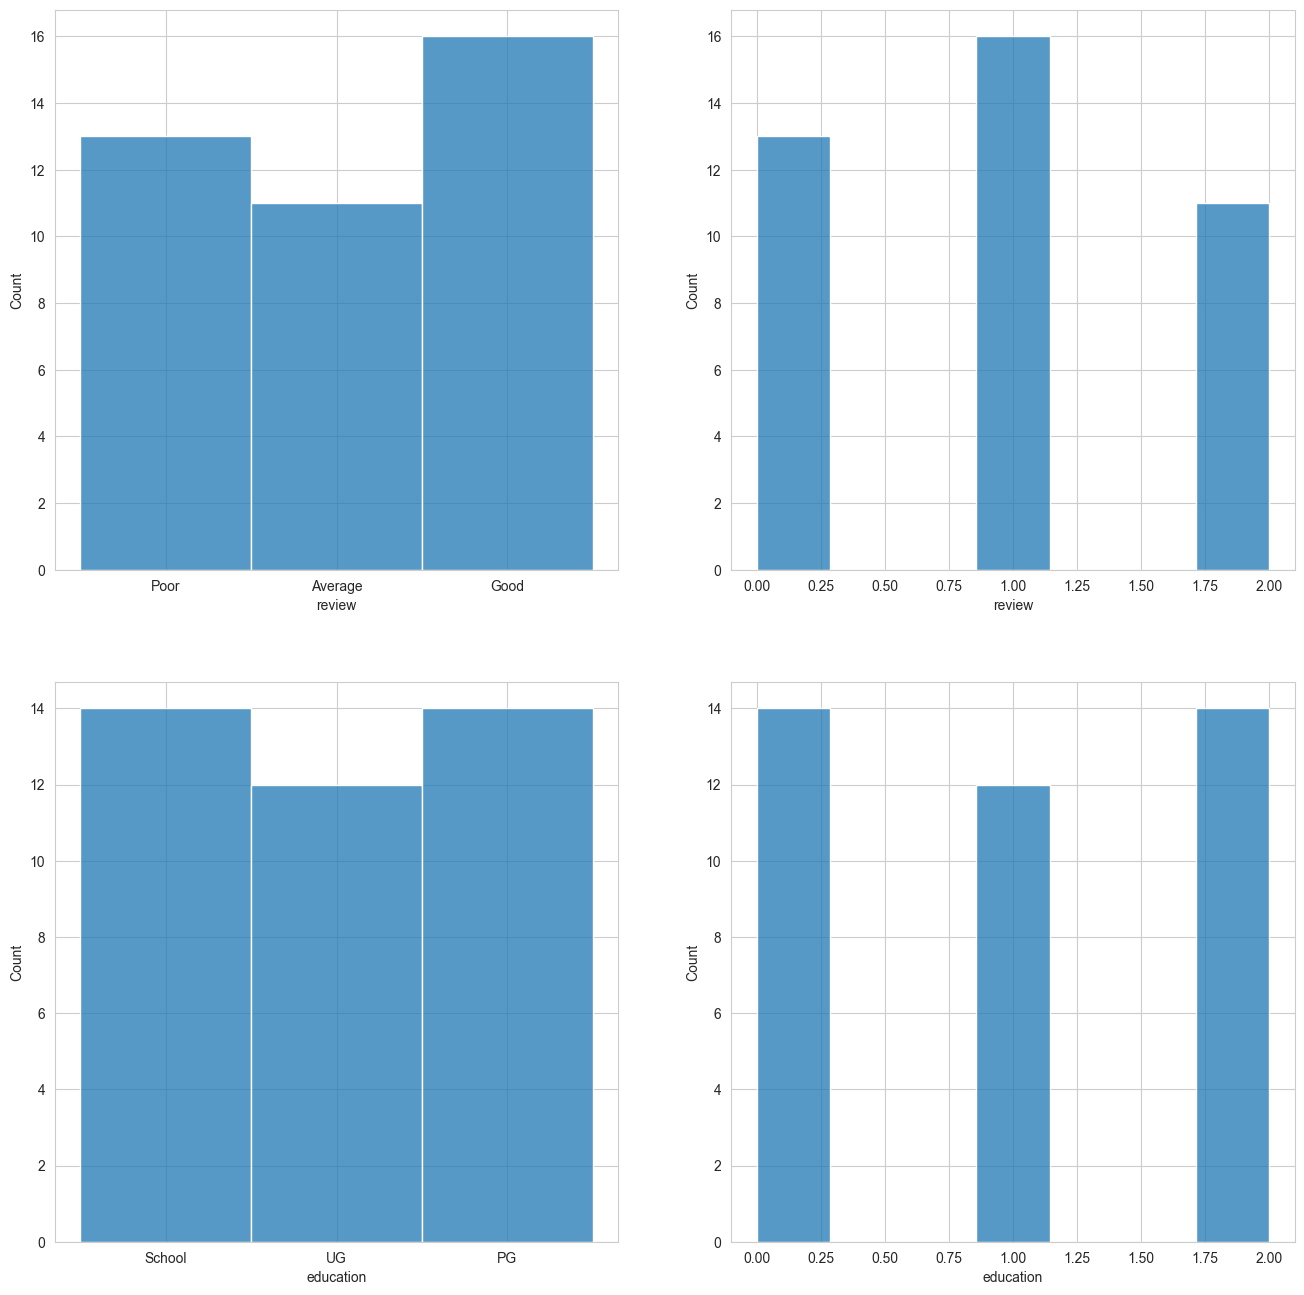

In [13]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(16,16))
sns.histplot(data=X_train, x='review', ax=ax[0,0])
sns.histplot(data=X_train_encoded, x='review', ax=ax[0,1])
sns.histplot(data=X_train, x='education', ax=ax[1,0])
sns.histplot(data=X_train_encoded, x='education', ax=ax[1,1])

# Label Encoding for y

In [14]:
from sklearn.preprocessing import LabelEncoder

lb = LabelEncoder()
y_train_encoded = lb.fit_transform(y_train)
y_test_encoded = lb.transform(y_test)

# Test model 

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
lr = LogisticRegression()
lr.fit(X_train_encoded, y_train_encoded)
y_pred = lr.predict(X_test_encoded)
accuracy_score(y_test_encoded, y_pred)

0.5